In [1]:
import numpy as np
import pandas as pd
import scipy

import torch
from torch.utils.data import DataLoader
from torchinfo import summary

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams["font.sans-serif"] = ["IBM Plex Sans"]

# Testing dataloader, model & loss function

In [2]:
from vinson.dataset import SequenceEmbeddingDataset
from vinson.model import (
    BassetTrunkEmbed,
    CellEmbedding,
    EmbedModel,
)

from vinson.loss import poisson_loss

# Create model
embed = CellEmbedding(n_inputs=637, n_layers=1)
trunk = BassetTrunkEmbed(embed.n_outputs)
model = EmbedModel(trunk, embed, regression=True)

In [4]:
summary(model)

Layer (type:depth-idx)                   Param #
EmbedModel                               --
├─BassetTrunkEmbed: 1-1                  --
│    └─Sequential: 2-1                   --
│    │    └─Conv1d: 3-1                  23,100
│    │    └─BatchNorm1d: 3-2             600
│    │    └─ReLU: 3-3                    --
│    │    └─MaxPool1d: 3-4               --
│    └─ReLU: 2-2                         --
│    └─Sequential: 2-3                   --
│    │    └─Conv1d: 3-5                  660,200
│    │    └─BatchNorm1d: 3-6             400
│    │    └─ReLU: 3-7                    --
│    │    └─MaxPool1d: 3-8               --
│    └─ReLU: 2-4                         --
│    └─Sequential: 2-5                   --
│    │    └─Conv1d: 3-9                  280,200
│    │    └─BatchNorm1d: 3-10            400
│    │    └─ReLU: 3-11                   --
│    │    └─MaxPool1d: 3-12              --
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       25,800
│    └

(0.0, 50.0)

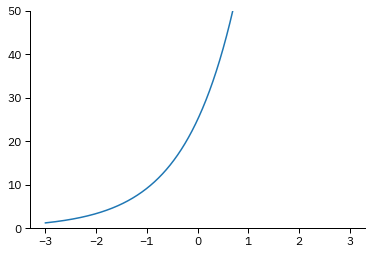

In [5]:
density = torch.tensor(0.0)
input = torch.linspace(-3, 3, 10_000)

read_depth = 25e6

pred_counts = (torch.exp(input) / 1e6 * read_depth) + 1e-6
target_counts = (density / 1e6 * read_depth) + 1e-6

loss = poisson_loss(pred_counts, target_counts, reduction="none")

plt.plot(input, loss)

plt.ylim(0, 50)

### Load in dataset and dataloader

In [6]:
eval_samples_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/JUL10/continious_annotation/data_JUL10.batch2.val.h5"

embeddings_file = "/home/jvierstra/proj/vinson/data/embeddings.tsv"
read_depth_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/JUL10//continious_annotation/total_cutcounts.tsv"

fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"

dataset = SequenceEmbeddingDataset(
    eval_samples_file,
    embeddings_file,
    read_depth_file,
    fasta_file,
    reverse_complement=True,
    jitter=0,
    noise=0,
)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
    drop_last=True,
)

Opening samples file...
Loading embeddings...
Loading sample read depths...
Done!


# Train model

To train model edit and run the following script: ```sbatch train.sh```

# Analyze, predict & interpret model

### Load in pre-trained variant model

In [21]:
pretrained_state_dict = torch.load(
    "models/regression_data_JUL10.batch1_v4_poisson_test/checkpoints/last.ckpt",
    map_location=torch.device("cpu"),
)["state_dict"]

model.load_state_dict(pretrained_state_dict)

<All keys matched successfully>

### Predict variants (random batch)

In [63]:
batch = next(iter(dataloader))

X_seq, X_embed, indicator, density, read_depth, r, example_type = (
    batch["seq"],
    batch["embed"],
    batch["indicator"],
    batch["density"],
    batch["read_depth"],
    batch["r"],
    batch["class"],
)

y_ = model(X_seq, X_embed).squeeze().detach()

pred_counts = (torch.exp(y_) / 1e6 * read_depth) + 1
pred_counts = pred_counts.detach()

target_counts = (density / 1e6 * read_depth) + 1
target_counts = target_counts.detach()

density = density + 0.01

loss = poisson_loss(pred_counts, target_counts, reduction="none").detach()

print(f"loss = {loss.mean()}")

loss = 16.118898391723633


#### Predicted vs. observed read counts

In [64]:
colors = {
    "positive": "red",
    "negative": "blue",
    "gc_matched_negative": "black",
}

c = [colors[x] for x in example_type]

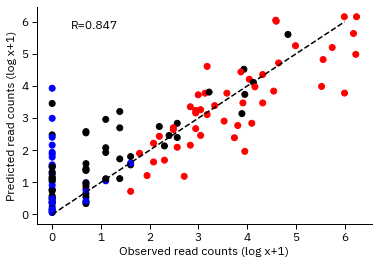

In [65]:
x = target_counts.log()
y = pred_counts.log()

plt.scatter(
    x,
    y,
    # c=(nll_pois - nll_pois_best).detach()
    c=c,
)

plt.plot([0, 6], [0, 6], color="k", ls="--")

plt.xlabel("Observed read counts (log x+1)")
plt.ylabel("Predicted read counts (log x+1)")

pearsonr = scipy.stats.pearsonr(x, y)

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

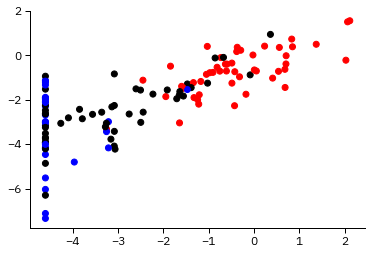

In [66]:
plt.scatter((density).log(), y_, c=c)

#### Predicted vs. observed peak densities

Text(0, 0.5, 'Peak density')

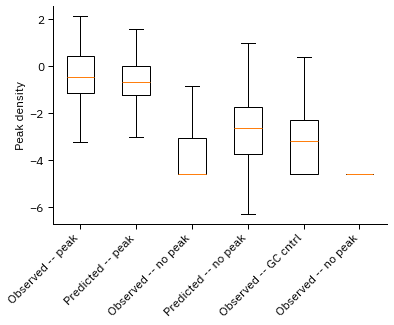

In [67]:
pred_w_peak = y_[indicator.to(bool)]
pred_wo_peak = y_[~indicator.to(bool)]

obs_w_peak = (density).log()[indicator.to(bool)]
obs_wo_peak = (density).log()[~indicator.to(bool)]

obs_gc_neg = (density).log()[np.array(example_type)=="gc_matched_negative"]
obs_neg = (density).log()[np.array(example_type)=="negative"]


y = [
    obs_w_peak,
    pred_w_peak,
    obs_wo_peak,
    pred_wo_peak,
    obs_gc_neg,
    obs_neg
]

b = plt.boxplot(y, showfliers=False)

plt.xticks(
    np.arange(1,7),
    labels = [
        "Observed -- peak",
        "Predicted -- peak",
        "Observed -- no peak",
        "Predicted -- no peak",
        "Observed -- GC cntrl",
        "Observed -- no peak",
    ], rotation=45, ha="right",
)

plt.ylabel("Peak density")

#### Loss landscape

Text(0.5, 1.0, 'Loss landscape for batch')

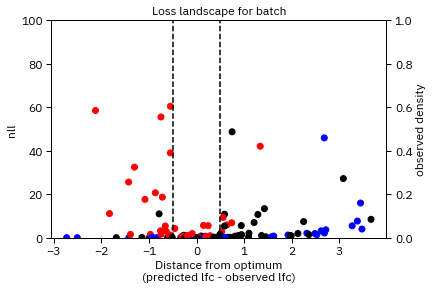

In [68]:
lfc = y_ - torch.log(density)

ax = plt.gca()

ax.scatter(lfc, loss, label="delta NLL", c=c)
ax.axvline(-0.5, color="k", ls="--")
ax.axvline(0.5, color="k", ls="--")

plt.xlabel("Distance from optimum\n(predicted lfc - observed lfc)")
ax.set_ylabel("nll")

ax.set_ylim(0, 100)

ax = ax.twinx()

# ax.scatter(lfc, density, c=indicator, label="Density")
ax.axhline(1, color="k", ls="--")

ax.set_ylabel("observed density")

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

plt.title("Loss landscape for batch")


#### Prediction error by peak density

Text(0.5, 1.0, 'Model prediction error by peak density')

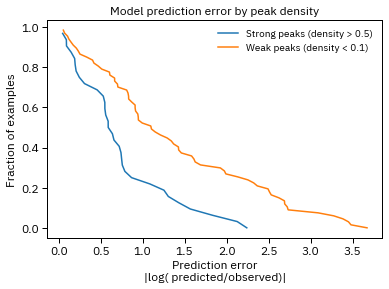

In [69]:
lfc_abs = lfc.abs()

x = lfc_abs[density > 0.5]
rank = np.arange(len(x)) / len(x)
plt.plot(np.sort(x)[::-1], rank, label="Strong peaks (density > 0.5)")

x = lfc_abs[density < 0.1]
rank = np.arange(len(x)) / len(x)
plt.plot(np.sort(x)[::-1], rank, label="Weak peaks (density < 0.1)")

plt.xlabel("Prediction error\n|log( predicted/observed)|")
plt.ylabel("Fraction of examples")

plt.legend()

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

plt.title("Model prediction error by peak density")

### Contribution scores

In [70]:
from tangermeme.deep_lift_shap import deep_lift_shap
from tangermeme.plot import plot_logo

In [71]:
print(torch.where(y_.exp() > 0.5))

(tensor([  2,   6,  14,  23,  24,  26,  47,  54,  55,  56,  59,  62,  70,  73,
         77,  85,  86,  87,  95, 100, 105, 108, 114, 115, 121, 123]),)


In [72]:
i = 14
torch.exp(y_[i]), density[i]

(tensor(0.5888), tensor(0.4424))

In [73]:
# Run DeepLIFT/SHAP
attributions = deep_lift_shap(
    model, 
    X_seq[i:i+1], 
    args=(X_embed[i:i+1],), 
    device="cpu",
    print_convergence_deltas=True
)

tensor([1.1921e-07, 7.1526e-07, 4.7684e-07, 7.1526e-07, 2.5332e-07, 2.3842e-07,
        4.7684e-07, 3.5763e-07, 0.0000e+00, 2.3842e-07, 0.0000e+00, 5.9605e-08,
        5.9605e-08, 4.1723e-07, 2.3842e-07, 2.3842e-07, 2.3842e-07, 0.0000e+00,
        4.7684e-07, 2.3842e-07], grad_fn=<AbsBackward0>)


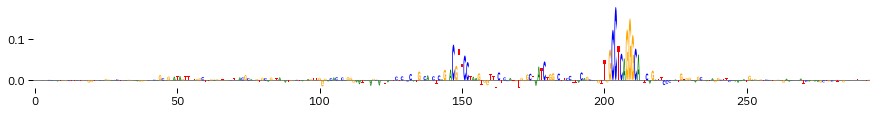

In [74]:
from tangermeme.plot import plot_logo

fig, ax = plt.subplots()
plot_logo(attributions[0][:,500:-550], ax=ax)
fig.set_size_inches(15, 1.5)